In [62]:
import math
import numpy as np 
import matplotlib.pyplot as plt    
%matplotlib inline

In [63]:
# defining scalar valued function
def f(x):
    return 3*x**2 - 4*x + 5

In [64]:
f(3.0)

20.0

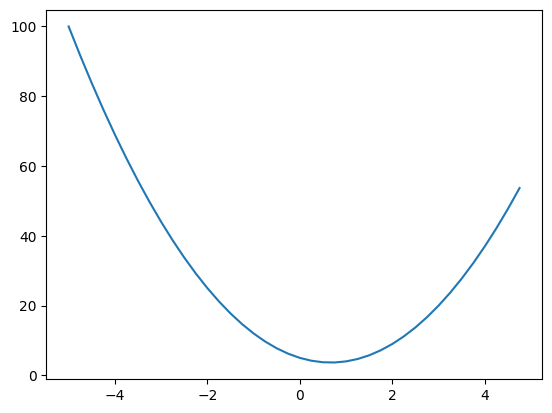

In [65]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [66]:
h = 0.000001
x = 2/3
(f(x + h) - f(x))/h

2.999378523327323e-06

In [67]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [68]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [129]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad # += for accumulating the gradients, avoiding overwrites for duplicates
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1-t**2) * out.grad
        out._backward = _backward
        return out
    
    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [130]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

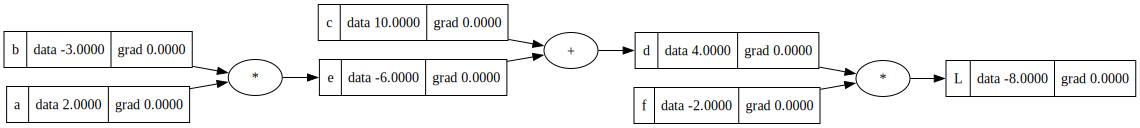

In [131]:
draw_dot(L)

In [132]:
L.grad = 1.0
d.grad = -2.0
f.grad = 4.0
# at + nodes, the local derivative is routed backwards to the children from the parent node. eg: 
# [chain rule] dL/dc = dL/dd * dd/dc = dL/dd * 1 for + node, by symmetry for e too at + node. hence:
c.grad = d.grad 
e.grad = d.grad 
# at * nodes, chain rule as well:
# dL/da = dL/de * dc/da = dL/dc * b, dL/db = dL/de * dc/db = dL/de * a
a.grad = e.grad * b.data
b.grad = e.grad * a.data

In [104]:
#from above, we can understand that backprop is basically a recursive application of the chain rule of derivatives

In [105]:
# example of a single gradient based optimization step to demonstrate the power of backprop, nudging leaf nodes (as we have control over them)
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

# 0.01 here is a hardcoded example of the learning rate / step size

# forward pass again
e = a*b
d = e + c
L = d * f

L.data

-7.286496

implementing backprop on a single neuron

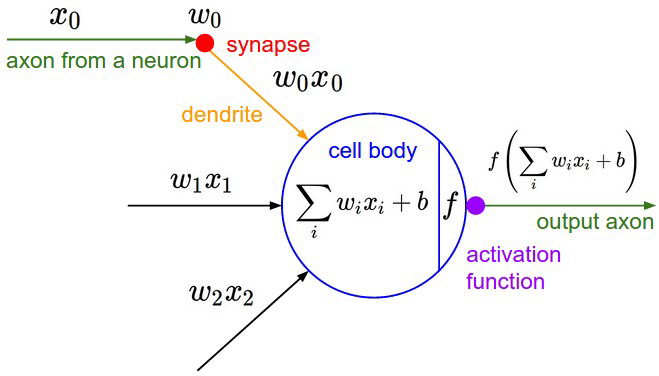

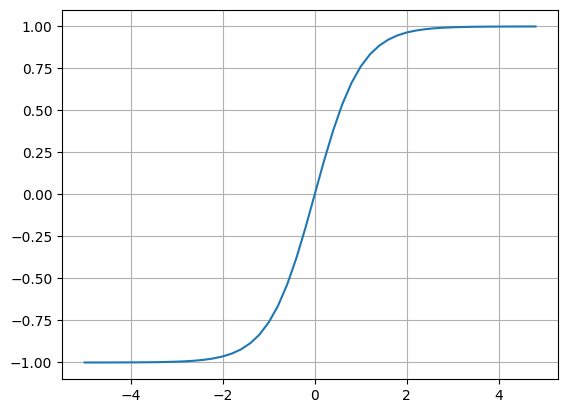

In [106]:
# example of an activation function (squashing function): tanh
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [133]:
# inputs x1,x2  (2d neuron)
x1 = Value (2.0, label='x1')
x2 = Value (0.0, label='x2')
# weights w1,w2 (synaptic strengths per input)
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
# cell body's raw activation
n = x1w1x2w2 + b; n.label = 'n'
# output with activation function
o = n.tanh(); o.label = 'o'

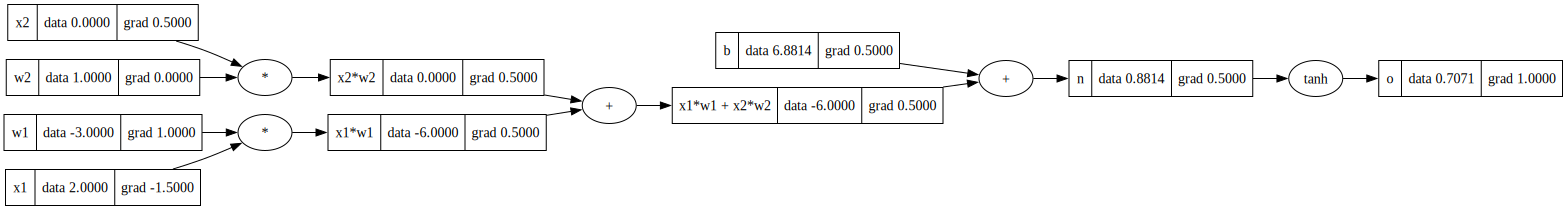

In [135]:
draw_dot(o)

In [134]:
o.backward()

In [114]:
# topological sort
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [ ]:
# implementing backpropogation with function _backward()
# call _backward for node only after its dependencies (future nodes) are set up [done through topological sort (see above)]
o.grad = 1.0
o._backward()
n._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

In [98]:
# manual backprop
o.grad = 1.0
# tanh grad
# do/dn = 1 - tanh(n)**2 = 1 - o**2
n.grad = 1 - (o.data)**2
# + node grad
x1w1x2w2.grad = n.grad
b.grad = n.grad
x1w1.grad = x1w1x2w2.grad
x2w2.grad = x1w1x2w2.grad
# * node grad
w1.grad = x1w1.grad * x1.data
x1.grad = x1w1.grad * w1.data
w2.grad = x2w2.grad * x2.data
x2.grad = x2w2.grad * w2.data